DATASET INFORMATION

Dataset shape:
(7816, 6)

First 20 rows:
           d1         d2         d3         d4         d5 NextWindowState
0   41.107247  42.488406  39.179707  30.658618  42.512355          ABSENT
1   42.488406  39.179707  30.658618  42.512355  39.159748          ABSENT
2   39.179707  30.658618  42.512355  39.159748  34.626767          ABSENT
3   30.658618  42.512355  39.159748  34.626767  41.088476          ABSENT
4   42.512355  39.159748  34.626767  41.088476  46.346986          ABSENT
5   39.159748  34.626767  41.088476  46.346986  44.929890          ABSENT
6   34.626767  41.088476  46.346986  44.929890  52.054262          ABSENT
7   41.088476  46.346986  44.929890  52.054262  46.179637          ABSENT
8   46.346986  44.929890  52.054262  46.179637  33.023785          ABSENT
9   44.929890  52.054262  46.179637  33.023785  35.628489          ABSENT
10  52.054262  46.179637  33.023785  35.628489  36.333671          ABSENT
11  46.179637  33.023785  35.628489  36.333671  42

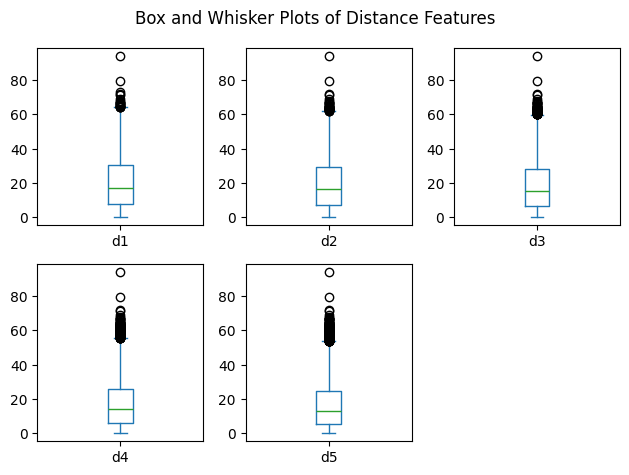

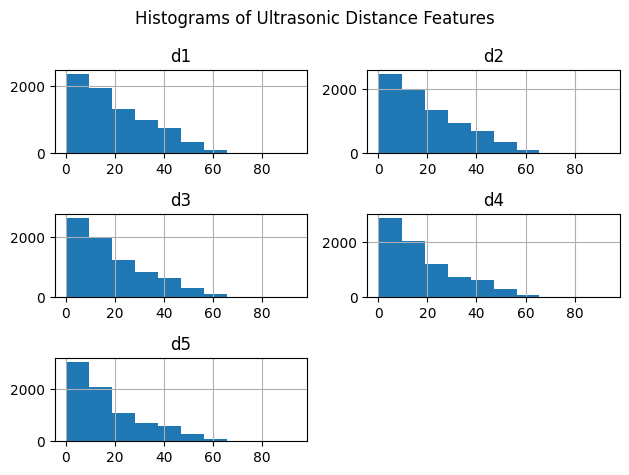

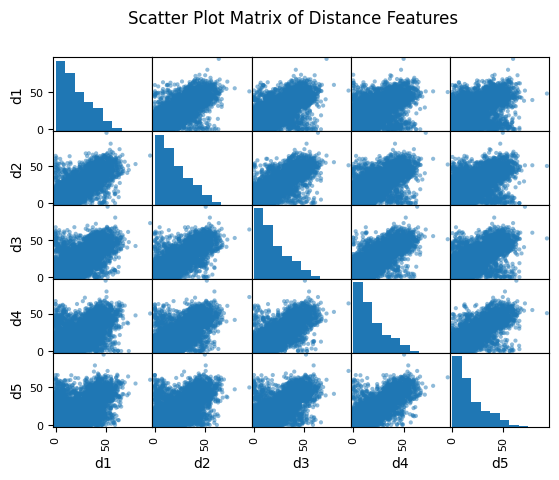


TRAIN / VALIDATION SPLIT
Training samples: 6252
Validation samples: 1564

10-FOLD CROSS-VALIDATION RESULTS
KNN: Mean Accuracy = 0.545432 | Std = 0.024307
CART: Mean Accuracy = 0.483052 | Std = 0.019291
SVM: Mean Accuracy = 0.441302 | Std = 0.014867


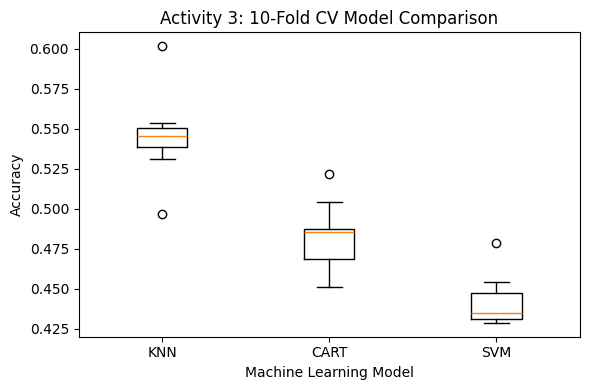


VALIDATION SET RESULTS

----------------------------------------
KNN
----------------------------------------
Validation Accuracy: 0.544757

Confusion Matrix:
[[312  52   9  18]
 [ 63 183  84  61]
 [ 16  82 213  80]
 [ 27  92 128 144]]

Classification Report:
              precision    recall  f1-score   support

      ABSENT       0.75      0.80      0.77       391
 APPROACHING       0.45      0.47      0.46       391
 MOVING_AWAY       0.49      0.54      0.52       391
     WAITING       0.48      0.37      0.41       391

    accuracy                           0.54      1564
   macro avg       0.54      0.54      0.54      1564
weighted avg       0.54      0.54      0.54      1564


----------------------------------------
CART
----------------------------------------
Validation Accuracy: 0.502558

Confusion Matrix:
[[281  53  20  37]
 [ 52 167  92  80]
 [ 22  92 173 104]
 [ 37  90  99 165]]

Classification Report:
              precision    recall  f1-score   support

      ABSEN

In [ ]:
# ============================================================
# ECE4810 LAB 2 - ACTIVITY 3
# SUPERVISED MACHINE LEARNING USING LAB 1 ULTRASONIC DATA
# ============================================================
#
# This code keeps the same overall structure as the sample
# machine-learning code provided in the Lab 2 PDF, but replaces
# the Iris dataset with the Lab 1 pedestrian ultrasonic dataset.
#
# Dataset file required:
#     pedestrian_windows.xlsx
#
# Expected columns:
#     d1, d2, d3, d4, d5, NextWindowState
#
# d1-d5 are five consecutive ultrasonic distance readings.
# These five readings form the input features for one sample.
# NextWindowState is the target class that the model predicts.
#
# Three supervised-learning algorithms are compared, following
# the Lab 2 sample:
#     1. K-Nearest Neighbours (KNN)
#     2. Classification and Regression Tree (CART)
#     3. Support Vector Machine (SVM)
#
# Evaluation methods:
#     - 80/20 training-validation split
#     - Stratified 10-fold cross-validation
#     - Validation accuracy
#     - Confusion matrix
#     - Precision, recall and F1-score
#
# No additional samples are generated in this code.
# ============================================================


# ============================================================
# 1. IMPORT REQUIRED LIBRARIES
# ============================================================
# pandas is used to read the Excel dataset.
# matplotlib is used for data visualisation.
# scikit-learn provides the ML algorithms and evaluation tools.
# ============================================================

from pandas import read_excel
from matplotlib import pyplot
from pandas.plotting import scatter_matrix

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score


# ============================================================
# 2. LOAD THE DATASET
# ============================================================
# The Lab 2 sample loads the Iris dataset from a URL.
# Here, the Lab 1 window dataset is stored locally as an Excel
# file, so read_excel() is used instead.
#
# Keep pedestrian_windows.xlsx in the same folder as this code.
# ============================================================

filename = "pedestrian_windows_despiked.xlsx"
dataset = read_excel(filename)


# ============================================================
# 3. CHECK DATASET SIZE AND CONTENT
# ============================================================
# dataset.shape returns:
#     (number of rows, number of columns)
#
# head(20) displays the first 20 samples so that the input
# columns and target column can be checked before training.
# ============================================================

print("========================================")
print("DATASET INFORMATION")
print("========================================")

print("\nDataset shape:")
print(dataset.shape)

print("\nFirst 20 rows:")
print(dataset.head(20))


# ============================================================
# 4. DESCRIPTIVE STATISTICS
# ============================================================
# describe() gives count, mean, standard deviation, minimum,
# quartiles and maximum for each numeric column.
#
# This provides a quick numerical description of the ultrasonic
# distance features before machine learning is applied.
# ============================================================

print("\nDataset description:")
print(dataset.describe())


# ============================================================
# 5. CLASS DISTRIBUTION
# ============================================================
# This counts how many samples belong to each target class.
# The result is useful for checking whether the classes are
# strongly imbalanced before model training.
# ============================================================

print("\nClass distribution:")
print(dataset.groupby("NextWindowState").size())


# ============================================================
# 6. BOX-AND-WHISKER PLOTS
# ============================================================
# Box plots show the median, spread and possible extreme values
# for each ultrasonic distance feature.
#
# NextWindowState is not plotted because it is a class label.
# ============================================================

dataset[["d1", "d2", "d3", "d4", "d5"]].plot(
    kind="box",
    subplots=True,
    layout=(2, 3),
    sharex=False,
    sharey=False
)

pyplot.suptitle("Box and Whisker Plots of Distance Features")
pyplot.tight_layout()
pyplot.show()


# ============================================================
# 7. HISTOGRAMS
# ============================================================
# Histograms show how frequently different distance values occur
# for d1-d5.
# ============================================================

dataset[["d1", "d2", "d3", "d4", "d5"]].hist()
pyplot.suptitle("Histograms of Ultrasonic Distance Features")
pyplot.tight_layout()
pyplot.show()


# ============================================================
# 8. SCATTER PLOT MATRIX
# ============================================================
# A scatter matrix compares pairs of input features.
# Since d1-d5 are consecutive readings, this also helps show the
# relationship between neighbouring measurements.
# ============================================================

scatter_matrix(dataset[["d1", "d2", "d3", "d4", "d5"]])
pyplot.suptitle("Scatter Plot Matrix of Distance Features")
pyplot.show()


# ============================================================
# 9. SEPARATE INPUT FEATURES AND TARGET LABEL
# ============================================================
# Dataset column order:
#     d1, d2, d3, d4, d5, NextWindowState
#
# X contains the five input distance features.
# y contains the target class.
#
# This follows the same array-splitting method used in the Lab 2
# sample code.
# ============================================================

array = dataset.values
X = array[:, 0:5]
y = array[:, 5]


# ============================================================
# 10. SPLIT INTO TRAINING AND VALIDATION DATA
# ============================================================
# 80% of the samples are used for training.
# 20% are kept as unseen validation data.
#
# random_state=1 makes the split repeatable.
# stratify=y keeps the class proportions similar in both sets.
# ============================================================

X_train, X_validation, Y_train, Y_validation = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=1,
    shuffle=True,
    stratify=y
)

print("\n========================================")
print("TRAIN / VALIDATION SPLIT")
print("========================================")
print("Training samples:", len(X_train))
print("Validation samples:", len(X_validation))


# ============================================================
# 11. DEFINE THE THREE BASELINE MODELS
# ============================================================
# KNN:
# Predicts a class based on nearby training samples.
#
# CART:
# Builds a decision tree by repeatedly splitting the feature
# space into regions that separate the classes.
#
# SVM:
# Finds a decision boundary that separates the classes.
# gamma="auto" is kept to match the structure of the sample code.
#
# These are baseline models. Activity 4 will investigate ways to
# improve them.
# ============================================================

models = []
models.append(("KNN", KNeighborsClassifier()))
models.append(("CART", DecisionTreeClassifier(random_state=1)))
models.append(("SVM", SVC(gamma="auto")))


# ============================================================
# 12. STRATIFIED 10-FOLD CROSS-VALIDATION
# ============================================================
# The training set is divided into 10 folds.
# For each round:
#     - 9 folds are used for training
#     - 1 fold is used for testing
#
# This is repeated until every fold has been used once for
# testing.
#
# CV Mean = average accuracy over the 10 folds.
# CV Std  = standard deviation of the 10 accuracy scores.
#
# A smaller CV standard deviation means the model performance is
# more consistent across the different folds.
# ============================================================

results = []
names = []

print("\n========================================")
print("10-FOLD CROSS-VALIDATION RESULTS")
print("========================================")

for name, model in models:
    kfold = StratifiedKFold(
        n_splits=10,
        random_state=1,
        shuffle=True
    )

    cv_results = cross_val_score(
        model,
        X_train,
        Y_train,
        cv=kfold,
        scoring="accuracy"
    )

    results.append(cv_results)
    names.append(name)

    print(
        "%s: Mean Accuracy = %.6f | Std = %.6f"
        % (name, cv_results.mean(), cv_results.std())
    )


# ============================================================
# 13. GRAPHICAL MODEL COMPARISON
# ============================================================
# The box plot shows the distribution of the 10 cross-validation
# scores for each model.
#
# A higher accuracy distribution with a smaller spread normally
# indicates better and more consistent performance.
# ============================================================

pyplot.figure(figsize=(6, 4))
pyplot.boxplot(results, tick_labels=names)
pyplot.title("Activity 3: 10-Fold CV Model Comparison")
pyplot.xlabel("Machine Learning Model")
pyplot.ylabel("Accuracy")
pyplot.tight_layout()
pyplot.show()


# ============================================================
# 14. VALIDATION SET EVALUATION FOR ALL MODELS
# ============================================================
# The Lab 2 example evaluates a selected model after the CV
# comparison. Here, all three models are evaluated so their
# validation results can be compared directly.
#
# Accuracy:
# Fraction of all validation predictions that are correct.
#
# Confusion matrix:
# Shows correct and incorrect predictions for each class.
#
# Precision:
# Of the samples predicted as a class, how many were correct.
#
# Recall:
# Of the actual samples in a class, how many were detected.
#
# F1-score:
# Harmonic mean of precision and recall.
# ============================================================

validation_accuracies = []

print("\n========================================")
print("VALIDATION SET RESULTS")
print("========================================")

for name, model in models:
    model.fit(X_train, Y_train)
    predictions = model.predict(X_validation)

    accuracy = accuracy_score(Y_validation, predictions)
    validation_accuracies.append(accuracy)

    print("\n----------------------------------------")
    print(name)
    print("----------------------------------------")
    print("Validation Accuracy: %.6f" % accuracy)

    print("\nConfusion Matrix:")
    print(confusion_matrix(Y_validation, predictions))

    print("\nClassification Report:")
    print(classification_report(Y_validation, predictions))


# ============================================================
# 15. FINAL ACTIVITY 3 SUMMARY
# ============================================================
# This output collects the main values required for the report:
#     - CV mean accuracy
#     - CV standard deviation
#     - Validation accuracy
# ============================================================

print("\n========================================")
print("ACTIVITY 3 FINAL MODEL COMPARISON")
print("========================================")

for i in range(len(names)):
    print(
        "%s | CV Mean = %.4f | CV Std = %.4f | "
        "Validation Accuracy = %.4f"
        % (
            names[i],
            results[i].mean(),
            results[i].std(),
            validation_accuracies[i]
        )
    )


# ============================================================
# 16. IDENTIFY THE BEST VALIDATION MODEL
# ============================================================
# This prints the model with the highest validation accuracy.
#
# For the written discussion, do not rely on validation accuracy
# alone. Also compare CV mean, CV standard deviation, confusion
# matrix, precision, recall and F1-score.
# ============================================================

best_index = validation_accuracies.index(max(validation_accuracies))
best_model = names[best_index]
best_accuracy = validation_accuracies[best_index]

print("\n========================================")
print("BEST ACTIVITY 3 MODEL")
print("========================================")
print("Best Model:", best_model)
print("Best Validation Accuracy: %.4f" % best_accuracy)


ACTIVITY 4 DATASET INFORMATION

Dataset shape:
(7816, 6)

Class distribution:
NextWindowState
ABSENT         1954
APPROACHING    1954
MOVING_AWAY    1954
WAITING        1954
dtype: int64

Training samples: 6252
Validation samples: 1564

BASELINE 10-FOLD CV RESULTS
KNN: Mean Accuracy = 0.545432 | Std = 0.024307
CART: Mean Accuracy = 0.483052 | Std = 0.019291
SVM: Mean Accuracy = 0.441302 | Std = 0.014867

KNN TUNING RESULTS
Best KNN parameters:
{'kneighborsclassifier__n_neighbors': 11, 'kneighborsclassifier__weights': 'distance'}
Best KNN CV Accuracy: 0.571978

CART TUNING / PRUNING RESULTS
Best CART parameters:
{'ccp_alpha': 0.0, 'max_depth': 7, 'min_samples_leaf': 1}
Best CART CV Accuracy: 0.538552

SVM TUNING RESULTS
Best SVM parameters:
{'svc__C': 10, 'svc__gamma': 'scale'}
Best SVM CV Accuracy: 0.565742

IMPROVED 10-FOLD CV RESULTS
KNN: Mean Accuracy = 0.571978 | Std = 0.023420
CART: Mean Accuracy = 0.538552 | Std = 0.022901
SVM: Mean Accuracy = 0.565742 | Std = 0.022962


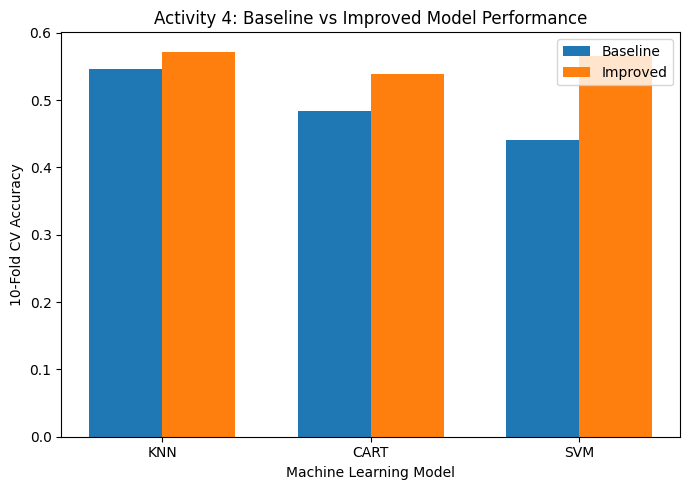


IMPROVED VALIDATION SET RESULTS

----------------------------------------
KNN
----------------------------------------
Validation Accuracy: 0.560102

Confusion Matrix:
[[311  50   9  21]
 [ 44 188  84  75]
 [ 11  59 215 106]
 [ 20  90 119 162]]

Classification Report:
              precision    recall  f1-score   support

      ABSENT       0.81      0.80      0.80       391
 APPROACHING       0.49      0.48      0.48       391
 MOVING_AWAY       0.50      0.55      0.53       391
     WAITING       0.45      0.41      0.43       391

    accuracy                           0.56      1564
   macro avg       0.56      0.56      0.56      1564
weighted avg       0.56      0.56      0.56      1564


----------------------------------------
CART
----------------------------------------
Validation Accuracy: 0.528133

Confusion Matrix:
[[304  58   7  22]
 [ 47 206  65  73]
 [ 10  98 179 104]
 [ 20 136  98 137]]

Classification Report:
              precision    recall  f1-score   support

  

In [ ]:
# ============================================================
# ECE4810 LAB 2 - ACTIVITY 4
# METHODS TO IMPROVE MACHINE-LEARNING PERFORMANCE
# ============================================================
#
# Activity 4 keeps the same dataset and the same three models
# used in Activity 3:
#     1. K-Nearest Neighbours (KNN)
#     2. Classification and Regression Tree (CART)
#     3. Support Vector Machine (SVM)
#
# The objective is to improve model performance using methods
# that can be clearly justified and compared with the Activity 3
# baseline.
#
# Improvement methods used here:
#     - StandardScaler for KNN
#     - Hyperparameter tuning for KNN
#     - CART pruning / complexity control
#     - Hyperparameter tuning for CART
#     - StandardScaler for SVM
#     - Hyperparameter tuning for SVM
#     - Stratified 10-fold cross-validation for model selection
#
# Random Forest, AdaBoost and ROC/AUC are not used.
# No additional samples are generated in this code.
# ============================================================


# ============================================================
# 1. IMPORT REQUIRED LIBRARIES
# ============================================================
# GridSearchCV tests multiple parameter combinations and chooses
# the combination with the best cross-validation score.
#
# StandardScaler standardises each input feature using:
#     z = (x - mean) / standard deviation
#
# make_pipeline keeps the scaling and model together so that the
# scaler is fitted correctly inside each CV fold.
# ============================================================

from pandas import read_excel
from matplotlib import pyplot

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score


# ============================================================
# 2. LOAD THE SAME DATASET USED IN ACTIVITY 3
# ============================================================
# Using the same dataset is necessary for a fair baseline vs
# improved comparison.
#
# Expected columns:
#     d1, d2, d3, d4, d5, NextWindowState
# ============================================================

filename = "pedestrian_windows_despiked.xlsx"
dataset = read_excel(filename)

print("========================================")
print("ACTIVITY 4 DATASET INFORMATION")
print("========================================")
print("\nDataset shape:")
print(dataset.shape)

print("\nClass distribution:")
print(dataset.groupby("NextWindowState").size())


# ============================================================
# 3. SEPARATE INPUT FEATURES AND TARGET
# ============================================================
# X = d1-d5 ultrasonic distance features
# y = NextWindowState class label
# ============================================================

array = dataset.values
X = array[:, 0:5]
y = array[:, 5]


# ============================================================
# 4. USE THE SAME 80/20 SPLIT AS ACTIVITY 3
# ============================================================
# Keeping the same split settings makes the Activity 3 and
# Activity 4 validation results directly comparable.
# ============================================================

X_train, X_validation, Y_train, Y_validation = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=1,
    shuffle=True,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Validation samples:", len(X_validation))


# ============================================================
# 5. CREATE ONE STRATIFIED 10-FOLD CV OBJECT
# ============================================================
# The same CV method is used for baseline evaluation, parameter
# tuning and improved-model evaluation.
# ============================================================

kfold = StratifiedKFold(
    n_splits=10,
    random_state=1,
    shuffle=True
)


# ============================================================
# 6. DEFINE THE ACTIVITY 3 BASELINE MODELS
# ============================================================
# These settings match Activity 3 so that the improvement can be
# measured against the same starting point.
# ============================================================

baseline_models = []
baseline_models.append(("KNN", KNeighborsClassifier()))
baseline_models.append(("CART", DecisionTreeClassifier(random_state=1)))
baseline_models.append(("SVM", SVC(gamma="auto")))


# ============================================================
# 7. BASELINE 10-FOLD CV RESULTS
# ============================================================
# Mean CV accuracy indicates average predictive performance.
# CV standard deviation indicates consistency across folds.
# ============================================================

baseline_results = []
baseline_std = []

print("\n========================================")
print("BASELINE 10-FOLD CV RESULTS")
print("========================================")

for name, model in baseline_models:
    cv_results = cross_val_score(
        model,
        X_train,
        Y_train,
        cv=kfold,
        scoring="accuracy"
    )

    baseline_results.append(cv_results.mean())
    baseline_std.append(cv_results.std())

    print(
        "%s: Mean Accuracy = %.6f | Std = %.6f"
        % (name, cv_results.mean(), cv_results.std())
    )


# ============================================================
# 8. IMPROVEMENT 1 - KNN SCALING + PARAMETER TUNING
# ============================================================
# KNN uses distance between samples. StandardScaler is included
# before KNN inside a pipeline.
#
# Parameters tested:
#
# n_neighbors:
# Number of neighbouring training samples used for the vote.
# A small k can be sensitive to local variation, while a larger
# k gives a smoother decision.
#
# weights:
# "uniform"  -> all neighbours vote equally
# "distance" -> closer neighbours receive greater influence
#
# GridSearchCV evaluates every listed parameter combination using
# the same stratified 10-fold CV method.
# ============================================================

knn_model = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier()
)

knn_parameters = {
    "kneighborsclassifier__n_neighbors": [3, 5, 7, 9, 11, 15],
    "kneighborsclassifier__weights": ["uniform", "distance"]
}

knn_grid = GridSearchCV(
    estimator=knn_model,
    param_grid=knn_parameters,
    scoring="accuracy",
    cv=kfold
)

knn_grid.fit(X_train, Y_train)

print("\n========================================")
print("KNN TUNING RESULTS")
print("========================================")
print("Best KNN parameters:")
print(knn_grid.best_params_)
print("Best KNN CV Accuracy: %.6f" % knn_grid.best_score_)


# ============================================================
# 9. IMPROVEMENT 2 - CART PRUNING / COMPLEXITY CONTROL
# ============================================================
# A decision tree can overfit if it becomes too deep and starts
# fitting very small details in the training data.
#
# max_depth:
# Limits the maximum tree depth.
#
# min_samples_leaf:
# Requires a minimum number of samples in each leaf.
#
# ccp_alpha:
# Cost-complexity pruning parameter. Increasing this value applies
# stronger pruning and can reduce unnecessary tree complexity.
#
# GridSearchCV searches for the combination with the highest
# cross-validation accuracy.
# ============================================================

cart_model = DecisionTreeClassifier(random_state=1)

cart_parameters = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_leaf": [1, 5, 10, 20],
    "ccp_alpha": [0.0, 0.001, 0.005]
}

cart_grid = GridSearchCV(
    estimator=cart_model,
    param_grid=cart_parameters,
    scoring="accuracy",
    cv=kfold
)

cart_grid.fit(X_train, Y_train)

print("\n========================================")
print("CART TUNING / PRUNING RESULTS")
print("========================================")
print("Best CART parameters:")
print(cart_grid.best_params_)
print("Best CART CV Accuracy: %.6f" % cart_grid.best_score_)


# ============================================================
# 10. IMPROVEMENT 3 - SVM SCALING + PARAMETER TUNING
# ============================================================
# StandardScaler is placed before SVM in a pipeline.
#
# C:
# Controls the trade-off between fitting the training samples and
# keeping a more general decision boundary.
#
# gamma:
# Controls the influence range of each training sample for the
# RBF kernel. Larger gamma can produce a more detailed boundary;
# lower gamma generally produces a smoother boundary.
# ============================================================

svm_model = make_pipeline(
    StandardScaler(),
    SVC()
)

svm_parameters = {
    "svc__C": [0.5, 1, 2, 4, 10],
    "svc__gamma": ["scale", 0.1, 0.05, 0.01]
}

svm_grid = GridSearchCV(
    estimator=svm_model,
    param_grid=svm_parameters,
    scoring="accuracy",
    cv=kfold
)

svm_grid.fit(X_train, Y_train)

print("\n========================================")
print("SVM TUNING RESULTS")
print("========================================")
print("Best SVM parameters:")
print(svm_grid.best_params_)
print("Best SVM CV Accuracy: %.6f" % svm_grid.best_score_)


# ============================================================
# 11. COLLECT THE BEST IMPROVED MODELS
# ============================================================
# best_estimator_ is the parameter combination selected by
# GridSearchCV for each algorithm.
# ============================================================

improved_models = []
improved_models.append(("KNN", knn_grid.best_estimator_))
improved_models.append(("CART", cart_grid.best_estimator_))
improved_models.append(("SVM", svm_grid.best_estimator_))


# ============================================================
# 12. IMPROVED 10-FOLD CV RESULTS
# ============================================================
# Re-evaluate the selected improved models using the same 10-fold
# CV method used for the baseline.
# ============================================================

improved_results = []
improved_std = []

print("\n========================================")
print("IMPROVED 10-FOLD CV RESULTS")
print("========================================")

for name, model in improved_models:
    cv_results = cross_val_score(
        model,
        X_train,
        Y_train,
        cv=kfold,
        scoring="accuracy"
    )

    improved_results.append(cv_results.mean())
    improved_std.append(cv_results.std())

    print(
        "%s: Mean Accuracy = %.6f | Std = %.6f"
        % (name, cv_results.mean(), cv_results.std())
    )


# ============================================================
# 13. GRAPH: BASELINE VS IMPROVED PERFORMANCE
# ============================================================
# The bar chart directly compares baseline mean CV accuracy with
# improved mean CV accuracy for KNN, CART and SVM.
# ============================================================

names = ["KNN", "CART", "SVM"]
x = range(len(names))
width = 0.35

pyplot.figure(figsize=(7, 5))

pyplot.bar(
    [i - width / 2 for i in x],
    baseline_results,
    width,
    label="Baseline"
)

pyplot.bar(
    [i + width / 2 for i in x],
    improved_results,
    width,
    label="Improved"
)

pyplot.xticks(x, names)
pyplot.ylabel("10-Fold CV Accuracy")
pyplot.xlabel("Machine Learning Model")
pyplot.title("Activity 4: Baseline vs Improved Model Performance")
pyplot.legend()
pyplot.tight_layout()
pyplot.show()


# ============================================================
# 14. VALIDATION SET EVALUATION OF IMPROVED MODELS
# ============================================================
# The same held-out validation set from Activity 3 is used here.
#
# For every improved model, print:
#     - Validation accuracy
#     - Confusion matrix
#     - Precision
#     - Recall
#     - F1-score
# ============================================================

validation_accuracies = []

print("\n========================================")
print("IMPROVED VALIDATION SET RESULTS")
print("========================================")

for name, model in improved_models:
    model.fit(X_train, Y_train)
    predictions = model.predict(X_validation)

    accuracy = accuracy_score(Y_validation, predictions)
    validation_accuracies.append(accuracy)

    print("\n----------------------------------------")
    print(name)
    print("----------------------------------------")
    print("Validation Accuracy: %.6f" % accuracy)

    print("\nConfusion Matrix:")
    print(confusion_matrix(Y_validation, predictions))

    print("\nClassification Report:")
    print(classification_report(Y_validation, predictions))


# ============================================================
# 15. FINAL BASELINE VS IMPROVED COMPARISON
# ============================================================
# Improvement is calculated as:
#     improved CV mean - baseline CV mean
#
# Positive improvement means the Activity 4 method increased the
# mean 10-fold CV accuracy compared with Activity 3.
# ============================================================

print("\n========================================")
print("ACTIVITY 4 FINAL COMPARISON")
print("========================================")

for i in range(len(names)):
    improvement = improved_results[i] - baseline_results[i]

    print(
        "%s | Baseline CV = %.4f | Improved CV = %.4f | "
        "CV Std = %.4f | Improvement = %.4f | "
        "Validation Accuracy = %.4f"
        % (
            names[i],
            baseline_results[i],
            improved_results[i],
            improved_std[i],
            improvement,
            validation_accuracies[i]
        )
    )


# ============================================================
# 16. IDENTIFY THE BEST IMPROVED MODEL
# ============================================================
# The highest validation accuracy is printed as a convenient
# summary.
#
# For the written Activity 4 justification, also compare:
#     - Baseline vs improved CV mean
#     - CV standard deviation
#     - Validation accuracy
#     - Confusion matrix
#     - Precision, recall and F1-score
#
# The important point is to explain WHY the selected improvement
# method produces better generalisation, not only that the final
# number is higher.
# ============================================================

best_index = validation_accuracies.index(max(validation_accuracies))
best_model = names[best_index]
best_accuracy = validation_accuracies[best_index]

print("\n========================================")
print("BEST IMPROVED MODEL")
print("========================================")
print("Best Model:", best_model)
print("Best Validation Accuracy: %.4f" % best_accuracy)
